# **Imports**

In [2]:
from utils_data import *

import os
import re
import glob
import json

import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

import rasterio
from rasterio.plot import show

##### set dataframe display options
pd.options.display.float_format = '{:.4f}'.format     # show decimal format (not scientific notation
pd.set_option('display.max_columns', None)            # display all columns

# **Model Performance Post-Processing**

In [3]:

def sort_key(path):
    dirname = os.path.basename(os.path.dirname(path))

    # Check explicitly for 'log' prefix
    is_log = dirname.startswith('log')
    base_name = dirname[3:] if is_log else dirname

    # Parse prefix and numeric/ms details
    match = re.match(r'^([a-zA-Z_]+?)(?:_(\d+)x(\d+)|_(\d+)|_(ms))?$', base_name)

    if match:
        prefix = match.group(1)
        if match.group(2) and match.group(3):  # NxN numeric format
            numeric = (int(match.group(2)), int(match.group(3)))
            num_flag = 1  # numeric
        elif match.group(4):  # single numeric (_10, etc.)
            numeric = (int(match.group(4)), -1)
            num_flag = 1  # numeric
        elif match.group(5) == 'ms':  # "_ms"
            numeric = (float('inf'), float('inf'))
            num_flag = 2  # ms entries
        else:  # non-numeric, non-ms
            numeric = (float('-inf'), float('-inf'))
            num_flag = 0  # non-numeric entries
    else:
        prefix = base_name
        numeric = (float('-inf'), float('-inf'))
        num_flag = 0

    # Final sorting criteria clearly defined:
    # (prefix alphabetical, log first, num_flag, numeric sorting)
    return (prefix, not is_log, num_flag, numeric)

In [4]:
indomain_performance_paths = glob.glob('../models/classification/*/label_metrics_tuned_hardin.csv')
indomain_performance_paths = sorted(indomain_performance_paths, key=sort_key)

accuracy = pd.DataFrame(columns=['modality', 'af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr', 'AVG.'])
precision = pd.DataFrame(columns=['modality', 'af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr', 'AVG.'])
recall = pd.DataFrame(columns=['modality', 'af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr', 'AVG.'])
f1 = pd.DataFrame(columns=['modality', 'af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr', 'AVG.'])
auc = pd.DataFrame(columns=['modality', 'af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr', 'AVG.'])

for idx, path in enumerate(indomain_performance_paths):
    modality = os.path.basename(os.path.dirname(path))
    df = pd.read_csv(path).T

    a = df.loc['Accuracy'].to_list()
    a.append(np.mean(a))
    a.insert(0, modality)
    accuracy.loc[idx] = a

    p = df.loc['Precision'].to_list()
    p.append(np.mean(p))
    p.insert(0, modality)
    precision.loc[idx] = p

    r = df.loc['Recall'].to_list()
    r.append(np.mean(r))
    r.insert(0, modality)
    recall.loc[idx] = r

    f = df.loc['F1'].to_list()
    f.append(np.mean(f))
    f.insert(0, modality)
    f1.loc[idx] = f

    au = df.loc['AUROC'].to_list()
    au.append(np.mean(au))
    au.insert(0, modality)
    auc.loc[idx] = au


accuracy.to_csv(r'../models/classification/performance_hardin_accuracy.csv', index=False)
precision.to_csv(r'../models/classification/performance_hardin_precision.csv', index=False)
recall.to_csv(r'../models/classification/performance_hardin_recall.csv', index=False)
f1.to_csv(r'../models/classification/performance_hardin_f1.csv', index=False)
auc.to_csv(r'../models/classification/performance_hardin_auc.csv', index=False)

# **Data**

In [23]:

# paths to patch locations GeoJSONs
patches_geojson = [r'../data/howevalley/hv_patches_256_50.geojson', 
                   r'../data/sonora/sonora_patches_256_50.geojson', 
                   r'../data/warren/patches_256_50.geojson']

# paths to patch labels (in-domain)
labels_path = glob.glob(r'../data/warren/*labels.csv')[0]
areas_path = glob.glob(r'../data/warren/*areas.csv')[0]

# paths to patch labels (cross-domain)
hv_labels_path = glob.glob(r'../data/howevalley/*labels.csv')[0]
sonora_labels_path = glob.glob(r'../data/sonora/*labels.csv')[0]

# hardin_areas_path = glob.glob(r'../data/hardin/*areas.csv')[0]

In [5]:
hardin_patches_geojson = r'../models/patches/hardin_patches_test.geojson'

gdf_hardin = gpd.read_file(hardin_patches_geojson)


gdf_hardin.shape

(1536, 2)

In [4]:
all_patches_path = r'../data/all_patches.geojson'

gdf = gpd.read_file(patches_geojson[0])
for p in patches_geojson[1:]:
    gdf2 = gpd.read_file(p)
    gdf = pd.concat([gdf, gdf2])

gdf.to_file(all_patches_path, driver='GeoJSON')

patch_ids = gdf['patch_id'].to_list()

In [5]:
all_counts_path = r'../data/all_counts.csv'

df_counts = pd.read_csv(labels_path)
df_counts = pd.concat([df_counts, pd.read_csv(hardin_labels_path)])

# df_counts.to_csv(all_counts_path, index=False)
counts = df_counts.iloc[:, 1:].sum(axis=0)
counts = pd.DataFrame(counts)

In [6]:
all_areas_path = r'../data/all_areas.csv'

df_areas = pd.read_csv(areas_path)
df_areas = pd.concat([df_areas, pd.read_csv(hardin_areas_path)])

# df_areas.to_csv(all_areas_path, index=False)

df_areas_longform = df_areas.iloc[:, 1:].melt(var_name='Geologic Map Unit', value_name='Proportion')

In [6]:
# path to JSON metadata
geo_meta_path = r'../data/warren/geology.json'

##### create custom color map from GeoTIFF metadata JSON
# NOTE: these are standard colors from Kentucky Geological Survey
with open(geo_meta_path, 'r') as meta:
    geo_meta = json.load(meta)

colors = {'af1': '#636566', 
          'Qal': '#fdf5a4', 
          'Qaf': '#ffa1db', 
          'Qat': '#f9e465', 
          'Qc': '#d6c9a7', 
          'Qca': '#c49d83', 
          'Qr': '#b0acd6'}

cmap = ListedColormap([colors[symbol] for symbol in geo_meta.keys()])


In [24]:
# df_hardin = pd.read_csv(hardin_labels_path)
# hardin_ids = df_hardin['patch_id'].to_list()

# **Modalities**

256_50_21983


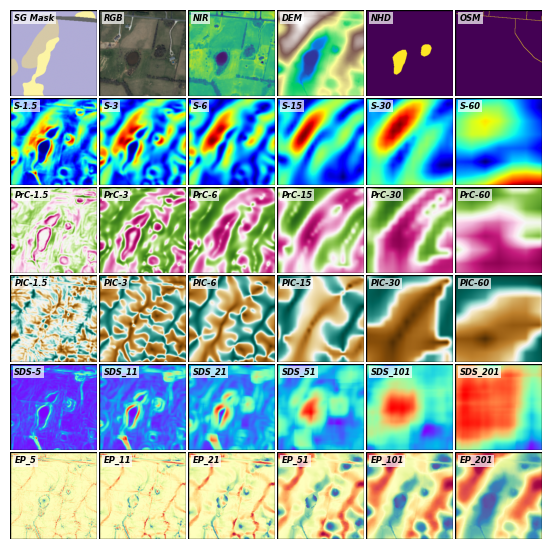

In [86]:


patches_dir = r'../data/patches_warren'
# random_patch = np.random.choice(gdf_warren['patch_id'], 1).item()
random_patch = '256_50_21983'
# output_path = f"../data/warren_{random_patch}_modalities.jpg"


# patches_dir = r'../data/patches_hardin'
# # random_patch = np.random.choice(gdf_hardin['patch_id'], 1).item()
# random_patch = 'hv_256_50_548'
# # output_path = f"../data/hardin_{random_patch}_modalities.jpg"


print(random_patch)


# prepare rgb or nir+gb (false color) image
rgb_image = []
for image in [f"{patches_dir}/{random_patch}_aerialr.tif", f"{patches_dir}/{random_patch}_aerialg.tif", f"{patches_dir}/{random_patch}_aerialb.tif"]:
    with rasterio.open(image) as src:
        data = src.read(1)
        rgb_image.append(data)
rgb_image = np.dstack(rgb_image) / 255


# plot images...
images_per_row = 6
subplot_width = 6.875 / images_per_row  
subplot_height = 6.875 / images_per_row 
fig, ax = plt.subplots(nrows=6, ncols=images_per_row, figsize=(images_per_row * subplot_width, 6 * subplot_height))
plt.subplots_adjust(hspace=0.02, wspace=0.02)
ax = ax.ravel()

# plot geology mask...
with rasterio.open(f"{patches_dir}/{random_patch}_geology.tif") as src:
    show(src, ax=ax[0], cmap=cmap, vmin=1, vmax=7)

# plot rgb or nir+gb...
ax[1].imshow(rgb_image)

# plot additional images...
additional = ['aerialnir.tif', 'dem.tif', 
              'nhd.tif', 'osm.tif',
              'slope.tif', 'slope_10.tif', 'slope_20.tif', 'slope_50.tif', 'slope_100.tif', 'slope_200.tif',
              'procurv.tif', 'procurv_10.tif', 'procurv_20.tif', 'procurv_50.tif', 'procurv_100.tif', 'procurv_200.tif',
              'plancurv.tif', 'plancurv_10.tif', 'plancurv_20.tif', 'plancurv_50.tif', 'plancurv_100.tif', 'plancurv_200.tif',
              'stdslope_5x5.tif', 'stdslope_11x11.tif', 'stdslope_21x21.tif', 'stdslope_51x51.tif', 'stdslope_101x101.tif', 'stdslope_201x201.tif',
              'ep_5x5.tif', 'ep_11x11.tif', 'ep_21x21.tif', 'ep_51x51.tif', 'ep_101x101.tif', 'ep_201x201.tif']

color_maps = ['viridis', 'terrain', 
              'viridis', 'viridis',
              'jet', 'jet', 'jet', 'jet', 'jet', 'jet',
              'PiYG', 'PiYG', 'PiYG', 'PiYG', 'PiYG', 'PiYG', 
              'BrBG', 'BrBG', 'BrBG', 'BrBG', 'BrBG', 'BrBG', 
              'rainbow', 'rainbow', 'rainbow', 'rainbow', 'rainbow', 'rainbow', 
              'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', 'Spectral_r', ]

for idx, (image, cmap2) in enumerate(zip(additional, color_maps), start=2):

    with rasterio.open(f"{patches_dir}/{random_patch}_{image}") as src:
        data = src.read(1)
        im = ax[idx].imshow(data, cmap=cmap2)

# plot labels...
for idx, title in enumerate(['SG Mask', 'RGB', 'NIR', 'DEM', 
                             'NHD', 'OSM', 
                             'S-1.5', 'S-3', 'S-6', 'S-15', 'S-30', 'S-60', 
                             'PrC-1.5', 'PrC-3', 'PrC-6', 'PrC-15', 'PrC-30', 'PrC-60', 
                             'PlC-1.5', 'PlC-3', 'PlC-6', 'PlC-15', 'PlC-30', 'PlC-60', 
                             'SDS-5', 'SDS_11', 'SDS_21', 'SDS_51', 'SDS_101', 'SDS_201', 
                             'EP_5', 'EP_11', 'EP_21', 'EP_51', 'EP_101', 'EP_201'], start=0):
    ax[idx].set_title(title, style='italic', weight='bold', size=6, y=0.78, x=0.05, loc='left', bbox=dict(facecolor='white', edgecolor='none', pad=1.0, alpha=0.7))
    # if (idx==4) or (idx==5):
    #     ax[idx].set_title(title, style='italic', weight='bold', size=6, y=0.0, color='white')



for axes in ax:
    axes.set_axis_off()
    rect = patches.Rectangle((0, 0), 1, 1, transform=axes.transAxes, linewidth=1, edgecolor='black', facecolor='none')
    axes.add_patch(rect)

# plt.savefig(output_path, dpi=500, bbox_inches='tight')
plt.savefig(f'/Users/matthew/Desktop/warren_{random_patch}_modalities.jpg', dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()


In [71]:
test = glob.glob(r'../data/patches_warren/256_50_20000_*slope*.tif')
test.sort()
test

['../data/patches_warren/256_50_20000_slope.tif',
 '../data/patches_warren/256_50_20000_slope_10.tif',
 '../data/patches_warren/256_50_20000_slope_100.tif',
 '../data/patches_warren/256_50_20000_slope_20.tif',
 '../data/patches_warren/256_50_20000_slope_200.tif',
 '../data/patches_warren/256_50_20000_slope_50.tif',
 '../data/patches_warren/256_50_20000_stdslope_101x101.tif',
 '../data/patches_warren/256_50_20000_stdslope_11x11.tif',
 '../data/patches_warren/256_50_20000_stdslope_201x201.tif',
 '../data/patches_warren/256_50_20000_stdslope_21x21.tif',
 '../data/patches_warren/256_50_20000_stdslope_51x51.tif',
 '../data/patches_warren/256_50_20000_stdslope_5x5.tif']

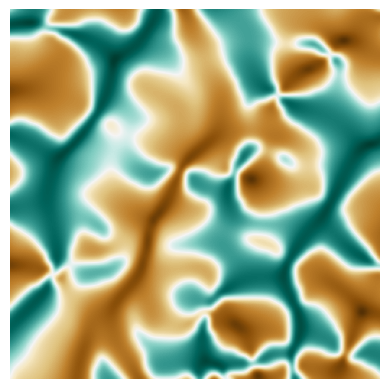

In [60]:
patches_dir = r'../data/patches_warren'
random_patch = '256_50_21983'

geo_meta_path = r'../data/warren/geology.json'
with open(geo_meta_path, 'r') as meta:
    geo_meta = json.load(meta)

colors = {'af1': '#636566', 
          'Qal': '#fdf5a4', 
          'Qaf': '#ffa1db', 
          'Qat': '#f9e465', 
          'Qc': '#d6c9a7', 
          'Qca': '#c49d83', 
          'Qr': '#b0acd6'}

cmap = ListedColormap([colors[symbol] for symbol in geo_meta.keys()])


rgb_image = []
for image in [f"{patches_dir}/{random_patch}_aerialr.tif", f"{patches_dir}/{random_patch}_aerialg.tif", f"{patches_dir}/{random_patch}_aerialb.tif"]:
    with rasterio.open(image) as src:
        data = src.read(1)
        rgb_image.append(data)
rgb_image = np.dstack(rgb_image) / 255


fig, ax = plt.subplots()

with rasterio.open(f"{patches_dir}/{random_patch}_plancurv_20.tif") as src:
    show(src, ax=ax, cmap='BrBG')

# ax.imshow(rgb_image)

ax.set_axis_off()

plt.savefig(r'/Users/matthew/Desktop/plc_20.png', dpi=300, bbox_inches='tight', pad_inches=0)

# **Class Distributions**

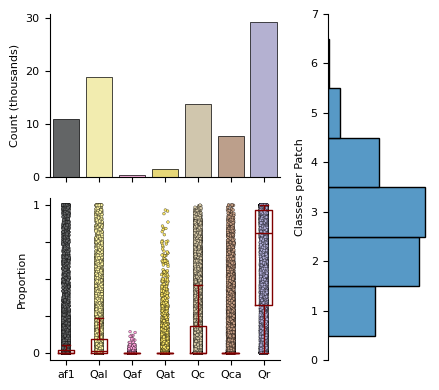

In [15]:
# Set up the figure and specify it as square
fig = plt.figure(figsize=(4.5, 4))
gs = gridspec.GridSpec(2, 2, width_ratios=[2.25,1], figure=fig)

# occurrence plot...
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(ax=ax1, data=counts, x=counts.index, y=0, hue=counts.index, palette=colors, edgecolor='k', linewidth=0.5)
ax1.set_xlabel('')
ax1.set_ylabel('Count (thousands)', size=8)
ax1.set_yticks([0, 10000, 20000, 30000])
ax1.set_yticklabels(['0', '10', '20', '30'], size=8)

# area plot...
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
# sns.histplot(ax=ax2, data=df_areas_longform, x='Geologic Map Unit', y='Proportion')
sns.boxplot(ax=ax2, data=df_areas_longform, x='Geologic Map Unit', y='Proportion', 
            showfliers=False, fill=False, color='#800000', width=0.5, linewidth=1)
sns.stripplot(ax=ax2, data=df_areas_longform, x='Geologic Map Unit', y='Proportion', hue='Geologic Map Unit', 
              palette=colors, alpha=1, zorder=0, linewidth=0.2, edgecolor='k', s=2)
ax2.set_xlabel('')
ax2.set_xticks(ax2.get_xticks())
ax2.set_xticklabels(ax2.get_xticklabels(), size=8)
ax2.set_ylabel('Proportion', size=8)
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(['0', '', '', '', '1'], size=8)

# patch label plot...
ax3 = fig.add_subplot(gs[:, 1])
patch_counts = df_counts.iloc[:, 1:].sum(axis=1)
sns.histplot(ax=ax3, y=patch_counts, discrete=True)
ax3.set_xlabel('')
ax3.set_ylabel('Classes per Patch', size=8, rotation=90)
ax3.set_yticks(ax3.get_yticks())
ax3.set_yticklabels(ax3.get_yticklabels(), size=8)
ax3.set_xticks([])

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_facecolor('#e3e3e3')
    # ax.grid(axis='y', color='k', linestyle='-', linewidth=0.25)

ax3.spines['top'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['right'].set_visible(False)

ax1.tick_params(labelbottom=False)

plt.tight_layout()

fig.savefig(r'../data/patch_stats.jpg', dpi=500)

plt.show()


In [ ]:
for x in df_areas.iloc[:, 1:]:
    fig, ax = plt.subplots(figsize=(5,5))
    sns.histplot(ax=ax, data=df_areas, x=x, bins=10, stat='percent')
    ax.set_title(x)
    plt.savefig(f'../data/area_hist_{x}.jpg', dpi=500)


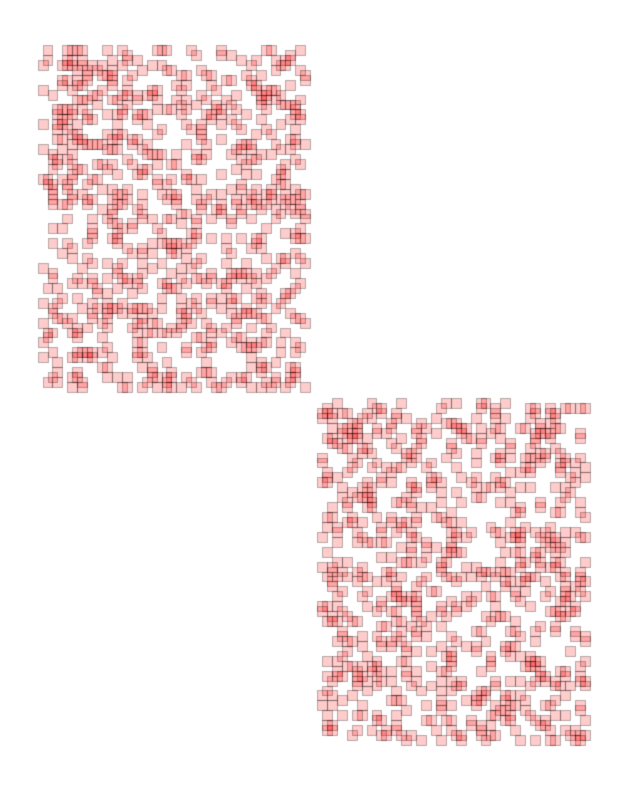

In [82]:
fig, ax = plt.subplots(figsize=(10,10))

gdf_hardin.plot(ax=ax, facecolor='red', edgecolor='k', linewidth=1, alpha=0.2,)

ax.set_axis_off()

plt.savefig(r'../models/patches/hardin_patches.jpg', dpi=500)

plt.show()

In [95]:
warren_train_path = r'../models/patches/warren_patches_train.geojson'
warren_val_path = r'../models/patches/warren_patches_val.geojson'
warren_test_path = r'../models/patches/warren_patches_test.geojson'
hardin_test_path = r'../models/patches/hardin_patches_test.geojson'

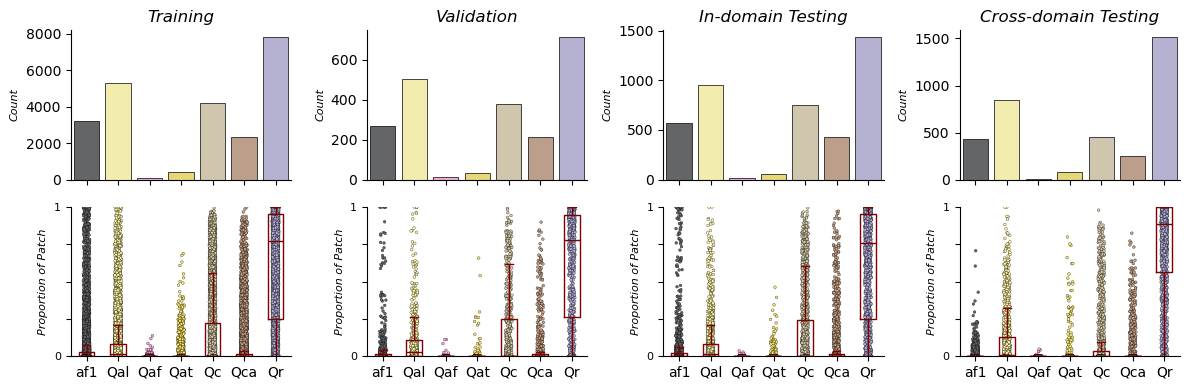

In [118]:

all_counts_path = r'../data/all_counts.csv'
df_counts = pd.read_csv(all_counts_path)

all_areas_path = r'../data/all_areas.csv'
df_areas = pd.read_csv(all_areas_path)

train_paths = [warren_train_path, warren_val_path, warren_test_path, hardin_test_path]


fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12,4))
ax = ax.ravel()
plt.subplots_adjust(wspace=0.2)
idx1 = 0
idx2 = 4

for path, name in zip(train_paths, ['Training', 'Validation', 'In-domain Testing', 'Cross-domain Testing']):
    gdf = gpd.read_file(path)
    id_list = gdf['patch_id'].to_list()

    counts = df_counts[df_counts['patch_id'].isin(id_list)]
    counts = counts.iloc[:, 1:].sum(axis=0)
    counts = pd.DataFrame(counts)
    
    areas = df_areas[df_areas['patch_id'].isin(id_list)].iloc[:, 1:]
    areas_long = areas.melt(var_name='Geologic Map Unit', value_name='Proportion')


    sns.barplot(ax=ax[idx1], data=counts, x=counts.index, y=0, hue=counts.index, palette=colors, edgecolor='k', linewidth=0.5)
    ax[idx1].set_xlabel('')
    ax[idx1].set_ylabel('Count', size=8, style='italic')


    sns.boxplot(ax=ax[idx2], data=areas_long, x='Geologic Map Unit', y='Proportion', 
            showfliers=False, fill=False, color='#800000', width=0.5, linewidth=1)
    sns.stripplot(ax=ax[idx2], data=areas_long, x='Geologic Map Unit', y='Proportion', hue='Geologic Map Unit', 
                palette=colors, alpha=1, zorder=0, linewidth=0.2, edgecolor='k', s=2)
    ax[idx2].set_xlabel('')
    ax[idx2].set_ylabel('Proportion of Patch', size=8, style='italic')
    ax[idx2].set_ylim(0,1)
    ax[idx2].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[idx2].set_yticklabels(['0', '', '', '', '1'], size=8)


    ax[idx1].set_title(name, style='italic')
    ax[idx1].spines['top'].set_visible(False)
    ax[idx1].spines['right'].set_visible(False)
    ax[idx1].tick_params(labelbottom=False)

    ax[idx2].spines['top'].set_visible(False)
    ax[idx2].spines['right'].set_visible(False)


    idx1 += 1
    idx2 += 1

plt.tight_layout()
plt.savefig(r'../data/distributions.jpg', dpi=500)
plt.show()

In [49]:
# [round(x-y, 3) for x,y in zip(in_auc_ep, cross_auc_ep)]

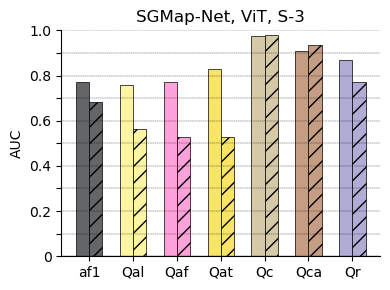

In [84]:
classes = ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr']

colors = {'af1': '#636566', 
          'Qal': '#fdf5a4', 
          'Qaf': '#ffa1db', 
          'Qat': '#f9e465', 
          'Qc': '#d6c9a7', 
          'Qca': '#c49d83', 
          'Qr': '#b0acd6'}

backbone = 'ViT'
model = 'Single'
modality = 'S-3'

in_auc_dem = [0.770, 0.759, 0.772, 0.829, 0.975, 0.910, 0.868]

cross_auc_dem = [0.683, 0.563, 0.528, 0.530, 0.981, 0.937, 0.772]

 


fig, ax = plt.subplots(figsize=(4,3))
plt.subplots_adjust(hspace=0.2)

x = np.arange(len(classes))
bar_width=0.3

ax.bar(x-bar_width / 2, in_auc_dem, bar_width, color=[colors[c] for c in classes], linewidth=0.5, edgecolor='k', label='In-domain')
ax.bar(x+bar_width / 2, cross_auc_dem, bar_width, color=[colors[c] for c in classes], linewidth=0.5, edgecolor='k', hatch='//', label='Cross-domain')

ax.set_xticks(x)
ax.set_xticklabels(classes) 

ax.set_yticks(np.arange(0,1.05,0.1))
ax.set_yticklabels(['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1.0'])
ax.set_ylim(0,1)

ax.set_title(f"SGMap-Net, {backbone}, {modality}")
ax.set_ylabel('AUC')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.grid(axis='y', lw=0.25, linestyle='--', color='k')


plt.tight_layout()
output_path = f"/Users/matthew/Desktop/{backbone}_{model}.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [95]:
output_path

'/Users/matthew/Desktop/Resnext_Single_top4.png'

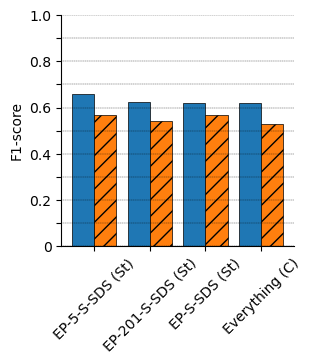

In [109]:


backbone = 'ViT'
model = 'Multimodal'

classes = ['EP-5-S-SDS (St)', 'EP-201-S-SDS (St)', 'EP-S-SDS (St)', 'Everything (C)']

in_f1 = [0.657, 0.622, 0.621, 0.621]

cross_f1 = [0.566, 0.544, 0.569, 0.528]

 


fig, ax = plt.subplots(figsize=(3,3))

x = np.arange(len(classes))
bar_width=0.4

ax.bar(x-bar_width / 2, in_f1, bar_width, color='tab:blue', linewidth=0.5, edgecolor='k', label='In-domain')
ax.bar(x+bar_width / 2, cross_f1, bar_width, color='tab:orange', linewidth=0.5, edgecolor='k', hatch='//', label='Cross-domain')



ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45) 

ax.set_yticks(np.arange(0,1.05,0.1))
ax.set_yticklabels(['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1.0'])
ax.set_ylim(0,1)

# ax.set_title(f"SGMap-Net, {backbone}, {model}")
ax.set_ylabel('F1-score')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', lw=0.25, linestyle='--', color='k')


# plt.tight_layout()
output_path = f"/Users/matthew/Desktop/{backbone}_{model}_top4.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()